<a href="https://colab.research.google.com/github/brendanpshea/database_sql/blob/main/Database_02_IntroToSQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to SQL: SELECT

*Database and SQL Through Pop Culture | Brendan Shea, PhD*

This chapter introduces the most-used parts of SQL. You will learn to retrieve data with `SELECT` and `FROM`, sort it with `ORDER BY`, filter it with `WHERE`, deal with `NULL` values, match patterns with `LIKE`, and summarize many rows at once using aggregate functions. The examples come from a real dataset of science-fiction books drawn from Goodreads.

## Learning Outcomes

By the end of this chapter, you will be able to:

1. Explain how relational databases use sets and logical conditions, and distinguish CRUD operations from the major categories of SQL statements.
2. Retrieve data with SELECT and FROM, including selecting all columns, specific columns, and DISTINCT values.
3. Sort and filter results with ORDER BY and WHERE.
4. Handle NULL values and pattern matching in query conditions.
5. Use aggregate functions, aliases with AS, and basic arithmetic or functions to summarize and label results.
6. Recognize core SQL syntax rules and explain why SQL dialects vary across database systems.

## Brendan's Lecture

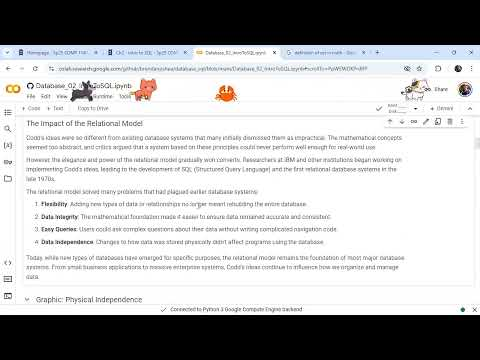

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('dcjw-klyEYA', width=800, height=500)


## Background: Why Databases Changed

Before computers, organizations stored information in paper files. Finding one record could require searching cabinets by hand, and updating or summarizing information was slow, repetitive, and error-prone.

That older approach created several recurring problems:

- Records could be misfiled or lost
- Only one person could use a file at a time
- Copying and updating information was tedious
- Reporting required manual review across many records

### Early electronic models

The first computer database systems largely copied those paper-era assumptions. **Hierarchical databases** organized information like a tree, while **network databases** allowed more flexible record-to-record links.

Both models were important steps forward, but they still made programmers think about storage paths and navigation details instead of focusing on the questions they wanted to ask.

### Why the relational model mattered

In 1970, Edgar F. Codd proposed the **relational model**, which reorganized data into tables and focused on describing *what* data to retrieve rather than *how* to walk through storage structures.

Key ideas behind the relational model:

1. Store data in tables of rows and columns
2. Use keys and relationships to connect tables
3. Query data declaratively with a high-level language
4. Separate logical design from physical storage details

This shift made databases more flexible, easier to query, and easier to maintain. It also set the stage for SQL and the database systems most people still use today.

### Graphic: Physical Independence

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the physical independence visualization](https://brendanpshea.github.io/database_sql/_static/games/physical-independence-visualization.html)

## Sets and Logic: How SQL Thinks About Data

Imagine a big box of baseball cards. Each card has the same fields: the player's name, team, batting average, and so on. In SQL, this is like a table — each card is a row, each field is a column. But SQL doesn't think about the cards one at a time. It thinks about them as a **set**.

### What is a set?

A **set** is a collection where:

- Each item appears only once (no duplicates).
- The order doesn't matter.

These all describe the same set:

- {apple, banana, orange}
- {banana, orange, apple}
- {orange, apple, banana}

SQL treats a table the same way. A `Students` table is a set of student records. Each student appears once, and the order doesn't matter.

Here is our creative writing school example:

| StudentID | Name | Grade | DateOfBirth |
|-----------|------|-------|-------------|
| 1001 | Virginia Woolf | A | 1882-01-25 |
| 1002 | Ernest Hemingway | B+ | 1899-07-21 |
| 1003 | Maya Angelou | A | 1928-04-04 |

To find all the A-grade students, we're asking SQL to build a new set: the rows where `Grade = 'A'`. In SQL:

```sql
SELECT * FROM Students WHERE Grade = 'A';
```

In English: "Give me the set of all students whose grade is A."

### True or false questions

When SQL filters rows, it asks true/false questions about each one. These questions are called **logical predicates**:

- "Is this student's grade an A?"
- "Is this student older than 20?"
- "Is this student in Poetry class?"

A `WHERE` clause is a list of these questions. SQL keeps only the rows where every question is true. For example:

```sql
SELECT * FROM Students WHERE Grade = 'A' AND StudentID > 1001;
```

SQL asks two questions about each student:

1. Is their grade an A?
2. Is their ID greater than 1001?

Both answers must be true for the row to survive.

### Describing what you want, not how to get it

One of the most interesting things about SQL is that you describe what you want, not how to find it. This style is called **declarative programming**.

Think of the difference between two ways of giving directions:

1. "Go straight for two blocks, turn right at the library, go one more block."
2. "Find the coffee shop on Oak Street."

The first gives step-by-step instructions. The second describes the goal. SQL works like the second one: you say what data you want, and the database figures out how to get it.

In a regular language like Python you might write:

```python
a_grade_students = []
for student in all_students:
    if student.grade == 'A':
        for enrollment in all_enrollments:
            if enrollment.studentID == student.studentID:
                if enrollment.classID == 'ENG101':
                    a_grade_students.append(student)
```

In SQL you describe the result instead:

```sql
SELECT Name
FROM Students
WHERE Grade = 'A'
  AND StudentID IN (
    SELECT StudentID
    FROM Enrollments
    WHERE ClassID = 'ENG101'
  );
```

You're telling SQL "the names of students who have an A and are enrolled in ENG101" — what, not how.

### Putting sets together

When we work with multiple tables, we're working with multiple sets. Our creative writing school has:

- A set of students
- A set of classes
- A set of enrollments (which students are in which classes)

Joining tables creates a new set by combining the originals based on how they relate:

```sql
SELECT Students.Name, Classes.Subject
FROM Students
JOIN Enrollments ON Students.StudentID = Enrollments.StudentID
JOIN Classes ON Enrollments.ClassID = Classes.ClassID;
```

This produces a new set whose rows mix information from all three tables — like fitting puzzle pieces together where they match.

By thinking in sets and predicates, SQL gives you a powerful way to work with data. You describe the result you want, and the database handles the rest.

## The Four Basic Database Operations: CRUD

Almost everything you do with a database falls into one of four basic operations, known as **CRUD**:

| Operation | What It Does | Basic SQL Command |
|-----------|-------------|-------------------|
| Create | Add new information | `INSERT INTO table_name` |
| Read | Look up or retrieve information | `SELECT FROM table_name` |
| Update | Change existing information | `UPDATE table_name` |
| Delete | Remove information | `DELETE FROM table_name` |

Think about managing a library catalog: you add new books (Create), look up books (Read), correct book information (Update), and remove books that are gone (Delete). The same pattern shows up in almost every database. Even when you use an app on your phone that saves information, CRUD is what is happening behind the scenes.

## The Five Parts of SQL

SQL is organized into five sub-languages, each designed for a specific kind of job.

### 1. Data Definition Language (DDL)

DDL creates and changes the **structure** of the database — the architect of the system:

| Command | Purpose | Example Use |
|---------|---------|-------------|
| `CREATE` | Make new tables or databases | Create a new `Students` table |
| `ALTER` | Modify existing tables | Add an `Email` column to `Students` |
| `DROP` | Remove tables or databases | Remove an old `Courses` table |
| `TRUNCATE` | Empty a table but keep its structure | Clear all data from `Grades` |

DDL decisions are usually permanent and shape how data can be stored. You'll use DDL most when first setting up a database or making major changes.

### 2. Data Manipulation Language (DML)

DML works with the **data inside** the tables — the librarian who manages the books:

| Command | Purpose | Example Use |
|---------|---------|-------------|
| `INSERT` | Add new data | Add a new student |
| `UPDATE` | Modify existing data | Change a student's grade |
| `DELETE` | Remove data | Remove a dropped student |
| `MERGE` | Combine data from multiple sources | Update grades from a spreadsheet |

These are the everyday commands. Unlike DDL, DML changes can usually be undone using TCL commands (covered below).

### 3. Data Query Language (DQL)

DQL searches and retrieves data — the detective who gathers information:

| Clause | Purpose | Example Use |
|--------|---------|-------------|
| `SELECT` | Choose which columns to see | Get student names and grades |
| `FROM` | Specify which tables to use | Look in the `Students` table |
| `WHERE` | Filter the results | Find all 'A' grade students |
| `ORDER BY` | Sort the results | Sort students by last name |
| `GROUP BY` | Organize data into groups | Group students by grade level |

DQL is technically part of DML, but `SELECT` is so important that it usually gets its own category. The real power comes from combining clauses — for example, finding all 'A' grade students in a particular class, listing just their names and emails, sorted alphabetically.

### 4. Data Control Language (DCL)

DCL manages **permissions** — the security guard:

| Command | Purpose | Example Use |
|---------|---------|-------------|
| `GRANT` | Give permissions | Allow teachers to view grades |
| `REVOKE` | Remove permissions | Remove access for former staff |

DCL lets you decide exactly who can do what. Teachers might be allowed to view and update grades, administrators to add or remove students, and students to view only their own records.

### 5. Transaction Control Language (TCL)

TCL ensures that database changes happen reliably — the accountant who keeps the books:

| Command | Purpose | Example Use |
|---------|---------|-------------|
| `BEGIN` | Start a group of changes | Start updating grades |
| `COMMIT` | Save all changes | Save all grade updates |
| `ROLLBACK` | Undo changes | Cancel incorrect updates |

A **transaction** is a group of related changes that should all succeed together or all fail together. Transferring money between bank accounts is the classic example: subtract from one account and add to another — both happen or neither does. TCL gives you that all-or-nothing guarantee, even if the network fails or the system crashes mid-operation.

These five sub-languages work together. Just as a school needs architects, teachers, administrators, and security guards, a database needs all five kinds of commands to function smoothly.

## SQL Standards and Varieties: How One Language Became Many

SQL started at IBM in the 1970s, originally called **SEQUEL** (Structured English Query Language). When other companies wanted similar database systems, it became clear everyone needed to speak the same language. Without a standard, every vendor's SQL would be different, making it hard to:

- Move from one database system to another.
- Build software that works with multiple databases.
- Train people once and have them work anywhere.

In 1986, the **American National Standards Institute (ANSI)** published the first official SQL standard. The **International Organization for Standardization (ISO)** later adopted it, making SQL an international standard. The standard has been revised many times since — 1989, 1992, 1999, 2003, 2006, 2008, 2011 — each version adding new features while keeping backward compatibility.

### Why "flavors" still exist

Despite the standard, different database systems still have their own **flavors** of SQL. Think of the standard like the rules of chess: everyone agrees on how the pieces move, but chess sets come in many styles and tournaments add their own house rules. SQL works the same way — every major system follows the core standard, then adds its own extensions.

The common varieties:

#### SQLite

SQLite is small, self-contained, and very versatile. Key features:

- The entire database lives in a single file.
- No separate server process is needed.
- Great for small applications, mobile devices, and learning.
- Built into many operating systems and browsers.

We use SQLite for most of this course because it lets us focus on SQL itself without database setup getting in the way.

#### PostgreSQL

PostgreSQL (often "Postgres") is feature-rich and aimed at serious work. Key features:

- Excellent compliance with the SQL standard.
- Support for complex queries and rich data types.
- Strong data integrity guarantees.
- Open source and actively maintained.

Later in the course we use Postgres for more advanced features.

#### Other common varieties

- **MySQL** — very popular for web applications.
- **Oracle** — common in large enterprises, known for reliability.
- **SQL Server** — Microsoft's database system, tightly integrated with Windows.
- **MariaDB** — an open-source fork of MySQL.

### How different are they really?

The core commands work the same in every major SQL database. If you write:

```sql
SELECT name FROM students WHERE grade = 'A';
```

…it works the same in SQLite, Postgres, MySQL, and the rest. Like driving a car: once you know the basics, every car has a steering wheel and pedals in roughly the same places.

The differences usually show up in:

- Advanced features.
- Performance tuning options.
- Admin commands.
- Supported data types.
- Built-in functions.

That is why we start with SQLite — learning the universal core first, then picking up system-specific features later.

## Getting Started With SQLite in Google Colab

Google Colab is a free, browser-based Jupyter notebook environment for running Python (and a lot more) in the cloud. It's a convenient place to write and test SQL because everything lives in one page.

For SQL we use the **SQL magic extension**. It lets you write SQL directly in notebook cells by starting the cell with `%%sql`. The next code cell installs the extension and loads it.

In [2]:
%pip install --quiet jupysql
%load_ext sql


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Now that we have the SQL magic extension loaded, we can connect to our SQLite database. In this case, we'll be using a pre-populated database file called `books.db`, which contains data about a collection of sci-fi books.

To load the `books.db` file into our Colab notebook, we can use the `wget` command to download it from a web link:

In [3]:
!wget -N 'https://github.com/brendanpshea/database_sql/raw/main/data/sci_fi_books.db' -q

Split-Path : Parameter set cannot be resolved using the specified named 
parameters.
At C:\Users\brend\OneDrive\Documents\Github\database_sql\wget.ps1:6 char:13
+ $repoRoot = Split-Path -LiteralPath $PSCommandPath -Parent
+             ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    + CategoryInfo          : InvalidArgument: (:) [Split-Path], ParameterBind 
   ingException
    + FullyQualifiedErrorId : AmbiguousParameterSet,Microsoft.PowerShell.Comma 
   nds.SplitPathCommand
 


Once the file is downloaded, we can connect to it using the SQL magic extension:

In [4]:
%config SqlMagic.autopandas=True
%sql sqlite:///sci_fi_books.db

Connecting to 'sqlite:///sci_fi_books.db'

This command establishes a connection to the `sci_fi_books.db` SQLite database file in our current working directory.

With the connection established, we can now run SQL queries on our database directly in our Colab notebook cells. For example, to see a list of all the tables in our database, we can use the following command.



In [5]:
%%sql
SELECT name FROM sqlite_master WHERE type='table';

Running query in 'sqlite:///sci_fi_books.db'

,name
0,books


## Getting to Know the Books Table

The data for this chapter comes from **Goodreads**, a social cataloging site for books. Goodreads users register the books they own, build reading lists, and share reviews and recommendations.

For our examples, we use a slice of Goodreads focused on science fiction. The data has been extracted and loaded into a SQLite database so we can explore it with SQL.

To work with any database effectively, you need to understand its **schema** — the blueprint that says what tables exist, what columns each table has, and what kind of data each column stores.

Here is the schema for the `books` table:

- `id` — A unique identifier for each book. This is the **PRIMARY KEY**, which means every row has its own value.
- `title` — The title of the book (TEXT).
- `series` — The name of the series, if the book is in one (TEXT).
- `author` — The author's name (TEXT).
- `rating` — The average Goodreads rating, stored as a REAL number (decimal).
- `language` — The language the book is written in (TEXT).
- `pages` — The number of pages (INTEGER).
- `publisher` — The publisher's name (TEXT).
- `numRatings` — The total number of Goodreads ratings (INTEGER).
- `firstPublishDate` — The date the book was first published (TEXT).
- `publishDate` — The most recent publication date (TEXT).

The schema tells us what kinds of questions we can ask. Because `rating` is a REAL number, we can compute averages on it. Because `pages` is an INTEGER, we can compare it against a number — for example, "all books over 500 pages." Knowing the schema is the first step to writing any useful query.

## SELECT and FROM

Now that we know the structure of the database, let's start writing queries. The two building blocks are `SELECT` and `FROM`.

The basic syntax of a `SELECT` query is:

```sql
SELECT column1, column2, ...
FROM table_name;
```

What each part means:

- `SELECT` — start of the query; lists the columns to return.
- `column1, column2, …` — the columns you want, separated by commas. Use `*` to get every column.
- `FROM` — names the table to read from.
- `table_name` — the table itself.

In plain English: *"Give me these columns from this table."*

### Selecting all columns

To return every column from the `books` table, use the `*` shorthand:

In [6]:
%%sql
SELECT * -- Select all columns
FROM Books -- From the Books table

Running query in 'sqlite:///sci_fi_books.db'

,firstPublishDate,publishDate,title,series,author,rating,language,pages,publisher,numRatings,id
0,NaN,2008-09-14,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,374.0,Scholastic Press,6376780,1
1,2003-06-21,2004-09-28,Harry Potter and the Order of the Phoenix,Harry Potter #5,J.K. Rowling,4.50,English,870.0,Scholastic Inc.,2507623,2
2,1945-08-17,1996-04-28,Animal Farm,NaN,George Orwell,3.95,English,141.0,Signet Classics,2740713,3
3,1956-10-28,2002-09-16,The Chronicles of Narnia,The Chronicles of Narnia (Publication Order) #...,C.S. Lewis,4.26,English,767.0,HarperCollins,517740,4
4,1955-10-20,2012-09-25,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,The Lord of the Rings #0-3,J.R.R. Tolkien,4.60,English,1728.0,Ballantine Books,110146,5
...,...,...,...,...,...,...,...,...,...,...,...
6586,NaN,1998-04-02,To Hold Infinity,NaN,John Meaney,3.73,English,560.0,Bantam,141,6599
6587,NaN,2015-10-01,The Natural Way of Things,NaN,Charlotte Wood,3.53,English,320.0,Allen & Unwin,10894,6600
6588,NaN,1983-01-01,Arafel's Saga,Arafel #1-2,C.J. Cherryh,3.69,English,408.0,"Nelson Doubleday, Inc.",1070,6601
6589,NaN,2017-01-12,Nameless Fate,Fated Mate #1,Stephanie West,3.93,English,445.0,NaN,508,6602


### Selecting specific columns
If we only want to retrieve certain columns, we can list them explicitly after the SELECT keyword:

In [7]:
%%sql
SELECT
  title, -- Select the title column
  author, -- Select the author column
  publishDate-- Select the publishDate column
FROM Books -- From the Books table
LIMIT 10; -- Limit the result to the first 10 rows

Running query in 'sqlite:///sci_fi_books.db'

,title,author,publishDate
0,The Hunger Games,Suzanne Collins,2008-09-14
1,Harry Potter and the Order of the Phoenix,J.K. Rowling,2004-09-28
2,Animal Farm,George Orwell,1996-04-28
3,The Chronicles of Narnia,C.S. Lewis,2002-09-16
4,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,2012-09-25
5,The Hitchhiker's Guide to the Galaxy,Douglas Adams,2007-06-23
6,Fahrenheit 451,Ray Bradbury,2011-11-29
7,Divergent,Veronica Roth,2012-02-28
8,Ender's Game,Orson Scott Card,2004-09-30
9,Harry Potter and the Sorcerer's Stone,J.K. Rowling,2003-11-01


###  Selecting DISTINCT values
Sometimes, you might want to retrieve only the unique values from a column. You can do this using the DISTINCT keyword:

In [8]:
%%sql
SELECT DISTINCT author -- Select distinct values from the author column
FROM Books -- From the Books table
LIMIT 10; -- Limit the result to the first 10 distinct authors

Running query in 'sqlite:///sci_fi_books.db'

,author
0,Suzanne Collins
1,J.K. Rowling
2,George Orwell
3,C.S. Lewis
4,J.R.R. Tolkien
5,Douglas Adams
6,Ray Bradbury
7,Veronica Roth
8,Orson Scott Card
9,Audrey Niffenegger


You can see the difference this makes if you try the same query WITHOUT using distinct.

In [9]:
%%sql
SELECT author -- Select all values from the author column
FROM Books -- From the Books table
LIMIT 15; -- Limit the result to the first 15 rows

Running query in 'sqlite:///sci_fi_books.db'

,author
0,Suzanne Collins
1,J.K. Rowling
2,George Orwell
3,C.S. Lewis
4,J.R.R. Tolkien
5,Douglas Adams
6,Ray Bradbury
7,Veronica Roth
8,Orson Scott Card
9,J.K. Rowling


You'll notice that some names (such as JK Rowling) appear twice. Sometimes, you'll want this (for example, if you are trying to count the number of books she wrote). Other times, though, you'll want to use DISTINCT to get rid of these "duplicates."

## ORDER BY

The `ORDER BY` clause sorts the rows of a result. The basic syntax:

```sql
SELECT column1, column2, ...
FROM table_name
ORDER BY column1 [ASC|DESC],
         column2 [ASC|DESC],
         ...;
```

How it works:

- `ORDER BY` is followed by the column(s) used for sorting.
- After each column you can add `ASC` (ascending — smallest to largest, A to Z) or `DESC` (descending — largest to smallest, Z to A). If you don't specify, `ASC` is the default.
- When you list more than one column, SQL sorts by the first column, then breaks ties using the second, and so on.

A simple example:

In [10]:
%%sql
SELECT
  title, -- Select the title column
  author, -- Select the author column
  rating -- Select the rating column
FROM Books -- From the Books table
ORDER BY rating -- Sort the results by rating in ascending order
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,rating
0,Revealing Eden,Victoria Foyt,1.99
1,Skull Flowers,Jazon Dion Fletcher,2.48
2,Ù…ÙˆØ³Ù… ØµÙŠØ¯ Ø§Ù„ØºØ²Ù„Ø§Ù†,Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯,2.74
3,Blueprint: Blaupause,Charlotte Kerner,2.78
4,Lost,Gregory Maguire,2.82
5,Redemption Prep,Samuel Miller,2.82
6,Alpha Centauri,William Barton,2.87
7,Corvus,L. Lee Lowe,2.90
8,Buck Rogers in the 25th Century: The Western P...,Paul S. Newman,2.91
9,L'an 2440,Louis-SÃ©bastien Mercier,2.92


We can also do this in descending order (with the highest ratings first)

In [11]:
%%sql
SELECT
  title, -- Select the title column
  author, -- Select the author column
  rating -- Select the rating column
FROM Books -- From the Books table
ORDER BY rating DESC -- Sort the results by rating in descending order
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,rating
0,"Kiss Me, I'm Irish",John Blandly,5.00
1,The Present,Kenneth Thomas,4.92
2,Maya of the Inbetween,Sita Bennett,4.86
3,Predestination: The Future is History,S. W. Cotton,4.85
4,The Beachhead,David Anderson,4.84
5,Assault On Utopia: Part 1,Steven P Sharp,4.80
6,Insectland,Neil D. Ostroff,4.80
7,"The Way of Kings, Part 2",Brandon Sanderson,4.79
8,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",J.K. Rowling,4.78
9,Words of Radiance,Brandon Sanderson,4.75


Finally, we can order by multiple columns (for example, by author and rating).

## WHERE

The `WHERE` clause filters rows. It lets you keep only the rows that match a condition.

The basic syntax:

```sql
SELECT column1, column2, ...
FROM table_name
WHERE condition;
```

How it works:

- `WHERE` is followed by a **condition** that each row must satisfy.
- The condition usually compares a column value against a constant, or compares two column values to each other.

Example: find all books with a rating higher than 4.5:

In [12]:
%%sql
SELECT
  title, -- Select the title column
  author, -- Select the author column
  rating -- Select the rating column
FROM Books -- From the Books table
WHERE rating > 4.5 -- Filter the results to only include books with a rating higher than 4.5
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,rating
0,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,4.60
1,Harry Potter and the Deathly Hallows,J.K. Rowling,4.62
2,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,4.57
3,Harry Potter and the Goblet of Fire,J.K. Rowling,4.56
4,Harry Potter and the Half-Blood Prince,J.K. Rowling,4.57
5,The Name of the Wind,Patrick Rothfuss,4.53
6,A Storm of Swords,George R.R. Martin,4.53
7,The Wise Man's Fear,Patrick Rothfuss,4.56
8,The Way of Kings,Brandon Sanderson,4.63
9,Harry Potter Series Box Set,J.K. Rowling,4.73


The condition can use these comparison operators:

- `=` — equal to
- `<>` or `!=` — not equal to
- `<` — less than
- `>` — greater than
- `<=` — less than or equal to
- `>=` — greater than or equal to

You can combine conditions with logical operators:

- `AND` — both conditions must be true.
- `OR` — at least one condition must be true.
- `NOT` — the condition must be false.

Example: find all books with more than 500 pages **and** more than 10,000 ratings:

In [13]:
%%sql
SELECT
  title,
  author,
  pages,
  numRatings
FROM
  Books
WHERE
  -- Long books that have many ratings
  pages > 500 AND numRatings > 10000
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,pages,numRatings
0,Harry Potter and the Order of the Phoenix,J.K. Rowling,870,2507623
1,The Chronicles of Narnia,C.S. Lewis,767,517740
2,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,1728,110146
3,A Game of Thrones,George R.R. Martin,835,2003043
4,Dune,Frank Herbert,661,765785
5,The Stand,Stephen King,1153,616021
6,Harry Potter and the Deathly Hallows,J.K. Rowling,759,2811637
7,The Fellowship of the Ring,J.R.R. Tolkien,527,2355237
8,Atlas Shrugged,Ayn Rand,1168,353814
9,Harry Potter and the Goblet of Fire,J.K. Rowling,734,2594622


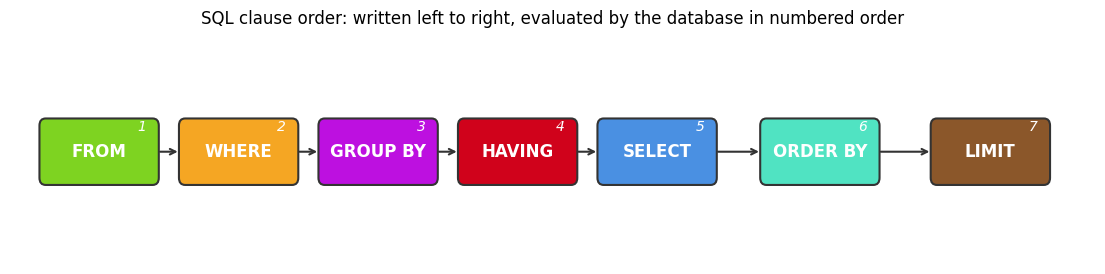

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

clauses = [
    ("FROM", "#7ED321", "1"),
    ("WHERE", "#F5A623", "2"),
    ("GROUP BY", "#BD10E0", "3"),
    ("HAVING", "#D0021B", "4"),
    ("SELECT", "#4A90E2", "5"),
    ("ORDER BY", "#50E3C2", "6"),
    ("LIMIT", "#8B572A", "7"),
]

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 2.4)
ax.axis("off")

x_positions = [0.4, 2.2, 4.0, 5.8, 7.6, 9.7, 11.9]
for (label, color, step), x in zip(clauses, x_positions):
    box = FancyBboxPatch(
        (x, 0.9), 1.5, 0.7,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.5, edgecolor="#333333", facecolor=color
    )
    ax.add_patch(box)
    ax.text(x + 0.75, 1.25, label, ha="center", va="center", color="white", fontweight="bold", fontsize=12)
    ax.text(x + 1.36, 1.53, step, ha="right", va="center", color="white", fontsize=10, style="italic")

for start, end in zip(x_positions, x_positions[1:]):
    ax.annotate("", xy=(end, 1.25), xytext=(start + 1.5, 1.25), arrowprops=dict(arrowstyle="->", lw=1.5, color="#333333"))

ax.set_title("SQL clause order: written left to right, evaluated by the database in numbered order", pad=18)
plt.show()

## SQLite Syntax Rules

Before going further, here are the basic rules for writing SQL in SQLite. A typical query looks like this:

```sql
SELECT column1, column2
FROM table_name
WHERE condition;
```

### Key Syntax Rules

#### 1. Semicolons (;)

End every SQL statement with a semicolon. The semicolon tells SQLite the statement is complete.

```sql
SELECT * FROM users;
```

#### 2. Capitalization

SQLite is **not** case-sensitive for keywords (`SELECT`, `FROM`, `WHERE`, etc.). Capitalizing them anyway is a common convention because it makes queries easier to read. Table and column names are case-sensitive only when they are wrapped in double quotes.

```sql
select * from Users;    -- works
SELECT * FROM users;    -- also works
SELECT * FROM "Users";  -- now case-sensitive
```

#### 3. Line breaks

A query can sit on one line or be split across many. SQLite ignores extra whitespace. Multi-line queries are usually easier to read.

```sql
SELECT name, age FROM users WHERE age > 18;

-- Equivalent:
SELECT name, age
FROM users
WHERE age > 18;
```

#### 4. Single vs. double quotes

- Single quotes (`'…'`) wrap string values.
- Double quotes (`"…"`) wrap table or column names that have spaces or need to be case-sensitive.

```sql
SELECT * FROM users WHERE name = 'Sam Q';
SELECT * FROM "User Table" WHERE "First Name" = 'Sam Q';
```

#### 5. Comments

- `--` starts a single-line comment.
- `/* … */` wraps a multi-line comment.

```sql
-- This is a single-line comment
SELECT * FROM users; /* This is a
multi-line comment */
```

## Handling NULL Values

In SQL, `NULL` is a special value that means *missing* or *unknown*. Working with `NULL` takes some care because it can lead to surprising results.

In our `books` table, both `series` and `firstPublishDate` have `NULL` values. For some books, the series is unknown or the book isn't in a series at all, and for others the original publication date is missing.

To check for `NULL` values in a `WHERE` clause, you use special operators:

- `IS NULL` — true when a value is missing.
- `IS NOT NULL` — true when a value is present.

Example: find all books that are part of a series (the `series` column is not `NULL`):

In [15]:
%%sql
SELECT
  title,
  author,
  series
FROM
  Books
WHERE
  -- books that ARE part of a series
  series IS NOT NULL
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,series
0,The Hunger Games,Suzanne Collins,The Hunger Games #1
1,Harry Potter and the Order of the Phoenix,J.K. Rowling,Harry Potter #5
2,The Chronicles of Narnia,C.S. Lewis,The Chronicles of Narnia (Publication Order) #...
3,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,The Lord of the Rings #0-3
4,The Hitchhiker's Guide to the Galaxy,Douglas Adams,The Hitchhiker's Guide to the Galaxy #1
5,Divergent,Veronica Roth,Divergent #1
6,Ender's Game,Orson Scott Card,Ender's Saga #1
7,Harry Potter and the Sorcerer's Stone,J.K. Rowling,Harry Potter #1
8,A Wrinkle in Time,Madeleine L'Engle,Time Quintet #1
9,A Game of Thrones,George R.R. Martin,A Song of Ice and Fire #1


Similarly, to find all books where the original publication date is unknown:

In [16]:
%%sql
SELECT
  title,
  author,
  firstPublishDate
FROM
  Books
WHERE
  -- books where the original publication date is unknown
  firstPublishDate IS NULL
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author,firstPublishDate
0,The Hunger Games,Suzanne Collins,None
1,Harry Potter and the Deathly Hallows,J.K. Rowling,None
2,Insurgent,Veronica Roth,None
3,The Maze Runner,James Dashner,None
4,The Selection,Kiera Cass,None
5,Catching Fire,Suzanne Collins,None
6,Uglies,Scott Westerfeld,None
7,Cinder,Marissa Meyer,None
8,The Wise Man's Fear,Patrick Rothfuss,None
9,Ready Player One,Ernest Cline,None


It's important to note that you cannot use the equality operator (=) to check for NULLs. For example, the following query will not return any results:

In [17]:
%%sql
SELECT
  title,
  author,
  firstPublishDate
FROM
  Books
WHERE
  firstPublishDate = NULL; -- This will not work as expected!

Running query in 'sqlite:///sci_fi_books.db'

,title,author,firstPublishDate


This is because in SQL, any comparison with NULL (even `NULL = NULL`) evaluates to NULL, which is treated as false in the context of a WHERE clause.

## LIKE

The `LIKE` operator searches for a **pattern** inside a text column. It is usually paired with `WHERE` to filter on partial matches rather than exact equality.

The basic syntax:

```sql
SELECT column1, column2, ...
FROM table_name
WHERE column LIKE pattern;
```

The pattern can include two wildcards:

- `%` — matches any sequence of zero or more characters.
- `_` — matches exactly one character.

A few examples:

- `title LIKE 'a%'` — any title starting with `a`.
- `title LIKE '%a'` — any title ending with `a`.
- `title LIKE '%a%'` — any title containing `a` anywhere.
- `title LIKE '_a%'` — any title with `a` as the second character.

In SQLite, `LIKE` is case-insensitive for ASCII characters by default.

### Example: Book titles starting with 'The'

To find all books whose title starts with "The":

In [18]:
%%sql
SELECT
  title,
  author
FROM
  Books
WHERE
  -- books whose title starts with "The"
  title LIKE 'The%'
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author
0,The Hunger Games,Suzanne Collins
1,The Chronicles of Narnia,C.S. Lewis
2,The Hitchhiker's Guide to the Galaxy,Douglas Adams
3,The Time Traveler's Wife,Audrey Niffenegger
4,The Princess Bride,William Goldman
5,The Handmaid's Tale,Margaret Atwood
6,The Giver,Lois Lowry
7,The Stand,Stephen King
8,The Fellowship of the Ring,J.R.R. Tolkien
9,The Road,Cormac McCarthy


### Example: Author Names Containing `Lewis`
Now, let's look for author names that contain "lewis" anywhere.

In [19]:
%%sql
SELECT
  title,
  author
FROM
  Books
WHERE
  -- author names that contain "lewis" anywhere
  author LIKE '%lewis%'
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,author
0,The Chronicles of Narnia,C.S. Lewis
1,The Voyage of the Dawn Treader,C.S. Lewis
2,The Last Battle,C.S. Lewis
3,The Silver Chair,C.S. Lewis
4,Prince Caspian,C.S. Lewis
5,Perelandra,C.S. Lewis
6,That Hideous Strength,C.S. Lewis
7,Space Trilogy: Out of the Silent Planet / Pere...,C.S. Lewis
8,Out of the Silent Planet,C.S. Lewis
9,It Can't Happen Here,Sinclair Lewis


## Aggregate Functions and Aliasing with AS

Aggregate functions take a set of rows and return a single value. The most common ones:

- `COUNT()` — counts the number of rows.
- `SUM()` — adds up the values in a column.
- `AVG()` — calculates the average of a column.
- `MAX()` — returns the largest value.
- `MIN()` — returns the smallest value.

### Examples of aggregate functions

Let's look at a few examples using the `books` table.

In [20]:
%%sql
--Find total number of books
SELECT
  COUNT(*) AS total_books
FROM
  Books;

Running query in 'sqlite:///sci_fi_books.db'

,total_books
0,6591


In [21]:
%%sql
--Average ratings of books
SELECT
  AVG(rating) AS avg_rating
FROM
  Books;

Running query in 'sqlite:///sci_fi_books.db'

,avg_rating
0,3.988885


In [22]:
%%sql
--Total number of pages across all books
SELECT
  SUM(pages) AS total_pages
FROM
  Books;

Running query in 'sqlite:///sci_fi_books.db'

,total_pages
0,2495231


In [23]:
%%sql
--Find maximum and minimum rating
SELECT
  MAX(rating) AS max_rating,
  MIN(rating) AS min_rating
FROM
  Books;

Running query in 'sqlite:///sci_fi_books.db'

,max_rating,min_rating
0,5.0,1.99


### Combining Aggregate Functions with WHERE Clauses
We can also combine aggregate functions with WHERE clauses to calculate values based on certain conditions.

In [24]:
%%sql
--Find the average rating of books after 2000
SELECT
  AVG(rating) AS avg_rating_after_2000
FROM
  Books
WHERE
  publishDate > 2000;

Running query in 'sqlite:///sci_fi_books.db'

,avg_rating_after_2000
0,3.994752


In [25]:
%%sql
--Find the number of books with more than 500 pages
SELECT
  COUNT(*) AS books_over_500_pages
FROM
  Books
WHERE
  pages > 500;

Running query in 'sqlite:///sci_fi_books.db'

,books_over_500_pages
0,1108


In [26]:
%%sql
--Find the maximum rating of books with more than 10,000 ratings
SELECT
  MAX(rating) AS max_rating_over_10000
FROM
  Books
WHERE
  numRatings >= 10000;

Running query in 'sqlite:///sci_fi_books.db'

,max_rating_over_10000
0,4.79


### Aliasing with AS

The `AS` keyword gives a column or an expression a temporary name — an **alias** — in the result. Aliases make output easier to read.

In the previous examples we used `AS` to label aggregate results: `total_books`, `avg_rating`, `max_rating`, and so on. Without those aliases, the column headers would show the full function expression instead, which is harder to read.

Aggregate functions paired with `AS` give you a fast way to summarize data. You can count rows, average values, find maximums and minimums, and label the results clearly — all in a single query.

## Basic Math Operations and Functions in SQL

SQL supports arithmetic directly inside a query. You can use it in `SELECT`, in `WHERE`, or alongside aggregate functions.

The arithmetic operators are:

- `+` — addition
- `-` — subtraction
- `*` — multiplication
- `/` — division
- `%` — modulo (remainder)

For example, suppose we want the price of a $20 book after a 10% discount:

In [27]:
%%sql
SELECT
  20 - (20 * 0.1) AS discounted_price;

Running query in 'sqlite:///sci_fi_books.db'

,discounted_price
0,18.0


SQL also provides built-in math functions. Some of the most common:

- `ROUND(number, decimal_places)` — rounds a number to a given number of decimal places.
- `FLOOR(number)` — returns the largest whole number less than or equal to the value.
- `CEIL(number)` or `CEILING(number)` — returns the smallest whole number greater than or equal to the value.
- `ABS(number)` — returns the absolute value.
- `SQRT(number)` — returns the square root.
- `POWER(number, power)` — raises the number to the given power.

For example, to see the average rating of each book rounded to one decimal place:

In [28]:
%%sql
--Get rounded rating
SELECT
  title,
  ROUND(rating, 1) AS rounded_rating
FROM
  Books
LIMIT 10;

Running query in 'sqlite:///sci_fi_books.db'

,title,rounded_rating
0,The Hunger Games,4.3
1,Harry Potter and the Order of the Phoenix,4.5
2,Animal Farm,4.0
3,The Chronicles of Narnia,4.3
4,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,4.6
5,The Hitchhiker's Guide to the Galaxy,4.2
6,Fahrenheit 451,4.0
7,Divergent,4.2
8,Ender's Game,4.3
9,Harry Potter and the Sorcerer's Stone,4.5


Mathematical operations and functions can be particularly useful when combined with aggregate functions.

For example, let's calculate the average number of pages across all books:

In [29]:
%%sql
--Calculate average number of pages, round to 0 decimal places
SELECT
  ROUND(AVG(pages), 0) AS avg_pages
FROM
  Books;

Running query in 'sqlite:///sci_fi_books.db'

,avg_pages
0,391.0


## Chapter Summary

Use this list as a self-check. After working through the chapter, you should be able to do each of the following:

- You can retrieve data with `SELECT` and `FROM`.
- You can sort results with `ORDER BY`.
- You can filter rows with `WHERE`.
- You can reason about `NULL` values in your queries.
- You can match patterns with `LIKE`.
- You can compute aggregates across sets of rows.
- You can rename columns and expressions with `AS` to improve readability.

## Lab Activity: Practice Your SQL (Highly Recommended!)
Really learning SQL requires hands on practice. You can "run" the following cell to launch a SQL practice app. Please let me (Brendan) know if you notice any issues with it, as it is still under development.

In [30]:
!wget https://github.com/brendanpshea/database_sql/raw/main/sql_select_quiz/sql_select_quiz.py -q -nc
from sql_select_quiz import sql_select_quiz_from_id
sql_select_quiz_from_id("books")

## Practice with the Loop of the Recursive Dragon

Sharpen what you just learned with a chapter-matched review set in the **Loop of the Recursive Dragon** — an adaptive review game with multiple question types and RPG-style mechanics, built for this book.

[**Launch the Chapter 2 review set →**](https://brendanpshea.github.io/LotRD/?set=database_02_select.json)

## Glossary

Use this list as a quick review sheet for the chapter.

### Relational and SQL basics

- **Relational model** — A way of organizing data into tables of rows and columns, with each row uniquely identifiable.
- **Table (relation)** — A collection of related records made up of rows and columns.
- **Row (record)** — A single entry in a table, holding one value for each column.
- **Column (field)** — A set of values of the same type, one per row.
- **Primary key** — A unique identifier for each row in a table.
- **Foreign key** — A column in one table that points to a primary key in another, creating a link between the two.
- **SQL** — Structured Query Language, the standard language for working with relational databases.
- **Declarative language** — A language in which you describe the result you want rather than the steps to compute it.
- **Query** — A request for information from a database.
- **SQLite** — A small, file-based relational database engine that needs no server.

### Core SQL keywords

- **`SELECT`** — Names the columns to return from a query.
- **`*`** — Shorthand that returns every column in a table.
- **`FROM`** — Names the table the query draws rows from.
- **`ORDER BY`** — Sorts the result set by one or more columns.
- **`ASC`** — Sorts results in ascending order; this is the default if not specified.
- **`DESC`** — Sorts results in descending order.
- **`LIMIT`** — Caps the number of rows the query returns.
- **`DISTINCT`** — Removes duplicate rows from the result set.
- **`WHERE`** — Filters rows to those that match a condition.
- **`AND`** — Combines conditions so that all of them must be true.
- **`OR`** — Combines conditions so that at least one must be true.
- **`NOT`** — Reverses a condition.
- **`IS NULL`** — Tests whether a value is missing or undefined.
- **`IS NOT NULL`** — Tests whether a value is present and defined.
- **`LIKE`** — Matches text against a pattern using wildcard characters.

### Pattern characters used with `LIKE`

- **`%`** — A wildcard that matches any sequence of zero or more characters.
- **`_`** — A wildcard that matches exactly one character.
- **`[CBA]`** — A character class that matches any single character listed in the brackets.
- **`[A-Z]`** — A character class that matches any single character in the given range.
- **`[^C]`** — A character class that matches any single character not listed in the brackets.

### Aggregate and math functions

- **`COUNT`** — Returns the number of rows in a group.
- **`SUM`** — Returns the total of a numeric column.
- **`AVG`** — Returns the average value of a numeric column.
- **`MAX`** — Returns the largest value in a column.
- **`MIN`** — Returns the smallest value in a column.
- **`ROUND`** — Rounds a number to a given number of decimal places.
- **`FLOOR`** — Returns the largest whole number less than or equal to a value.
- **`CEIL`** — Returns the smallest whole number greater than or equal to a value.
- **`AS`** — Gives a column or expression an alias in the result set.
- **`+`** — Adds two numeric values.
- **`-`** — Subtracts one numeric value from another.
- **`*` (math)** — Multiplies two numeric values.
- **`/`** — Divides one numeric value by another.
- **`%` (math)** — Returns the remainder after division (the modulo operator).